## **Task 2. Interpolation**

**Points: 2**

**Fill in the gaps of the missing data points embedded in each series. Indicate the uncertainty of your estimate for each point!**
• Evaluate how well your proposed solutions are expected to work.
• Make sure to avoid overfitting and data leakage in your models.
• Can you use insights from Task 1 to improve interpolation?

## 2. Approach

We interpolate the **internal** NaN gaps in each series. Each series has:
- One isolated 1-day gap at day 36 (sentinel `1000 → NaN`)
- One contiguous 50-day gap (at different positions per series)
- Four isolated 1-day gaps at days 1194, 2836, 3430, 4118

The **trailing 200-day block** (days 5257–5456) belongs to Task 3 and is left untouched.

### Methods

| Method | When used |
|--------|-----------|
| **Brownian Bridge (BB)** | Series with weak/no volatility clustering |
| **BB + GARCH(1,1)** | Series with significant volatility clustering |

**BB** interpolates log-prices by conditioning on both gap anchors (the last observed day before the gap and the first observed day after). This gives a distribution whose mean follows the straight line between anchors in log-space and whose variance is maximised at the midpoint.

**BB + GARCH(1,1)** additionally fits a GARCH model to pre-gap log-returns to obtain a time-varying conditional variance schedule. GARCH-simulated paths are then pinned at the post-gap anchor via a linear drift correction (standard bridge conditioning). This produces wider/narrower bands where the GARCH model expects high/low volatility.

**Classification criterion:** A series gets GARCH treatment if ACF(r²) at lag 1 > 0.10 **and** the Ljung–Box test on squared returns (10 lags) rejects at the 5% level. This criterion is motivated by the detailed analysis in Task 1.

**Uncertainty:** 500 simulated bridge paths per gap. The median is the point estimate; the 5th and 95th percentiles form the 90 % confidence band.

**Data-leakage policy:** GARCH parameters are estimated on log-returns strictly **before** the gap. The post-gap anchor price is used only as the bridge endpoint, which is legitimate in a smoothing/interpolation context. The trailing-200 block is never touched.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import acf as _acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# Check for arch package (needed for GARCH)
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
    print("arch package available — GARCH models enabled.")
except ImportError:
    ARCH_AVAILABLE = False
    print("WARNING: arch not installed. Install with:  pip install arch")
    print("Falling back to plain Brownian Bridge for all series.")

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

# ── Load and clean data ────────────────────────────────────────────────────
df_raw = pd.read_csv('../data/spiff_data-2.csv')
df_raw = df_raw.drop(columns=['Unnamed: 0']).set_index('day')
series_cols = df_raw.columns.tolist()
df = df_raw.replace(1000, np.nan)

TASK3_START = 5257   # first day of the trailing-200 Task-3 gap

print(f"\nLoaded: {len(df)} rows × {len(series_cols)} series")
print(f"Task-2 scope: internal gaps on days 1 – {TASK3_START - 1}")
print(f"Task-3 scope: trailing gap days {TASK3_START} – {df.index.max()} (left untouched)")

arch package available — GARCH models enabled.

Loaded: 5456 rows × 7 series
Task-2 scope: internal gaps on days 1 – 5256
Task-3 scope: trailing gap days 5257 – 5456 (left untouched)


In [10]:
# ── Identify internal NaN gaps (Task-2 scope only) ────────────────────────

def find_nan_gaps(s):
    """Return list of (start_day, end_day, length) for each contiguous NaN run."""
    is_nan = s.isna().values
    idx = s.index
    gaps, i, n = [], 0, len(is_nan)
    while i < n:
        if is_nan[i]:
            j = i
            while j < n and is_nan[j]:
                j += 1
            gaps.append((int(idx[i]), int(idx[j - 1]), j - i))
            i = j
        else:
            i += 1
    return gaps

def get_internal_gaps(s, exclude_from=TASK3_START):
    """Only gaps whose end day is strictly before `exclude_from`."""
    return [(a, b, l) for a, b, l in find_nan_gaps(s) if b < exclude_from]

print(f"{'Series':<14}  {'Gaps  (start, end, length)':<65}  Total NaN")
print("─" * 90)
for c in series_cols:
    gaps = get_internal_gaps(df[c])
    total = sum(l for _, _, l in gaps)
    print(f"{c:<14}  {str(gaps):<65}  {total}")

Series          Gaps  (start, end, length)                                         Total NaN
──────────────────────────────────────────────────────────────────────────────────────────
gurkor          [(36, 36, 1), (199, 248, 50), (1194, 1194, 1), (2836, 2836, 1), (3430, 3430, 1), (4118, 4118, 1)]  55
guitars         [(36, 36, 1), (399, 448, 50), (1194, 1194, 1), (2836, 2836, 1), (3430, 3430, 1), (4118, 4118, 1)]  55
slingshots      [(36, 36, 1), (599, 648, 50), (1194, 1194, 1), (2836, 2836, 1), (3430, 3430, 1), (4118, 4118, 1)]  55
stocks          [(36, 36, 1), (799, 848, 50), (1194, 1194, 1), (2836, 2836, 1), (3430, 3430, 1), (4118, 4118, 1)]  55
sugar           [(36, 36, 1), (999, 1048, 50), (1194, 1194, 1), (2836, 2836, 1), (3430, 3430, 1), (4118, 4118, 1)]  55
water           [(36, 36, 1), (1194, 1194, 1), (1199, 1248, 50), (2836, 2836, 1), (3430, 3430, 1), (4118, 4118, 1)]  55
tranquillity    [(36, 36, 1), (1194, 1194, 1), (1399, 1448, 50), (2836, 2836, 1), (3430, 3430, 1), (4118,

In [11]:
# ── Volatility clustering diagnostics ─────────────────────────────────────
# Use log-returns on observed data only (exclude Task-3 trailing gap)
df_obs = df.loc[1 : TASK3_START - 1]
log_ret = np.log(df_obs / df_obs.shift(1))

acf1_sq  = {}   # ACF of squared returns at lag 1
lb_pval  = {}   # Ljung-Box p-value on r² (10 lags)

for c in series_cols:
    r = log_ret[c].dropna()
    r2 = r ** 2
    acf1_sq[c] = float(_acf(r2, nlags=1, fft=True)[1])
    lb_pval[c]  = float(
        acorr_ljungbox(r2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    )

diag = pd.DataFrame({
    'ACF(r²) lag 1':            acf1_sq,
    'Ljung-Box p (r², 10 lags)': lb_pval,
})
print("Volatility-clustering diagnostics (log-returns, days 1–5256):\n")
print(diag.round(4).to_string())
print()

# ── Classify series ────────────────────────────────────────────────────────
ACF_THRESH   = 0.10   # ACF(r²) lag-1 threshold for GARCH treatment
MIN_PRE_OBS  = 60     # minimum pre-gap observations required to fit GARCH

garch_series, bb_series = [], []
for c in series_cols:
    use_garch = (
        ARCH_AVAILABLE
        and acf1_sq[c] > ACF_THRESH
        and lb_pval[c]  < 0.05
    )
    (garch_series if use_garch else bb_series).append(c)

print(f"→ Plain Brownian Bridge :      {bb_series}")
print(f"→ BB + GARCH(1,1)       :      {garch_series}")
print()
print("Note: even for GARCH-classified series, any individual gap where")
print("pre-gap data < 60 observations falls back to plain BB.")

Volatility-clustering diagnostics (log-returns, days 1–5256):

              ACF(r²) lag 1  Ljung-Box p (r², 10 lags)
gurkor               0.0645                     0.0000
guitars              0.1594                     0.0000
slingshots           0.3305                     0.0000
stocks              -0.0132                     0.7105
sugar                0.1127                     0.0000
water                0.1056                     0.0000
tranquillity         0.1115                     0.0000

→ Plain Brownian Bridge :      ['gurkor', 'stocks']
→ BB + GARCH(1,1)       :      ['guitars', 'slingshots', 'sugar', 'water', 'tranquillity']

Note: even for GARCH-classified series, any individual gap where
pre-gap data < 60 observations falls back to plain BB.


### Classification rationale (from Task 1 analysis)

| Series | ACF(r²) lag 1 | Verdict | Reason |
|--------|--------------|---------|--------|
| **sugar** | ≈ 0.60 | **GARCH** | Strongest volatility clustering in dataset; a violent spike-followed-by-spike around day 4100; excess kurtosis 10.69 |
| **slingshots** | ≈ 0.32 | **GARCH** | ACF(r²) persistent at 0.30–0.35 across all 40 lags; excess kurtosis 6.43; crash at day ≈ 4000 |
| **guitars** | ≈ 0.22 | **GARCH** | Second strongest GARCH signal; large volatility around days 2000–3000 and 4100; excess kurtosis 5.55 |
| tranquillity | ≈ 0.12 | **GARCH** | Moderate and decaying clustering; three-phase price path with a crash |
| gurkor | ≈ 0.05 | Plain BB | Only a minor GARCH effect; smooth trend with negligible clustering |
| water | ≈ 0.06 | Plain BB | Lowest rolling volatility of all series; ACF(r²) ≈ 0.05–0.10 |
| stocks | ≈ 0.00 | Plain BB | ACF of both r and r² ≈ white noise; near-Gaussian returns (excess kurtosis ≈ 0); no clustering |

In [12]:
N_SIM = 500   # number of simulated bridge paths per gap

# ── Brownian Bridge interpolation ──────────────────────────────────────────

def _bb_simulate(x_a, x_b, T, sigma, n_sim):
    """
    Simulate `n_sim` Brownian Bridge paths from x_a (t=0) to x_b (t=T).
    Returns array shape (n_sim, T-1): the T-1 internal time steps.

    Algorithm: generate T standard-normal increments, build a pinned BM.
      x_t = x_a + (t/T)*(x_b - x_a) + sigma*(BM_t - (t/T)*BM_T)
    where BM_t = cumsum(z)_t.  At t=T the correction term exactly removes BM_T.
    """
    n_internal = T - 1
    d = x_b - x_a
    paths = np.empty((n_sim, n_internal))
    for k in range(n_sim):
        z  = np.random.randn(T)
        bm = np.cumsum(z) * sigma          # unscaled BM (sigma already in log-price units)
        bm_T = bm[-1]
        for i in range(n_internal):
            s = i + 1                      # relative time 1 … T-1
            paths[k, i] = x_a + (s / T) * d + bm[i] - (s / T) * bm_T
    return paths


def interpolate_bb(log_price, gap_start, gap_end, n_sim=N_SIM, min_pre=60):
    """
    Plain Brownian Bridge in log-price space.
    Returns DataFrame indexed by gap days with columns: median, p05, p95, method.
    """
    a_day = gap_start - 1
    b_day = gap_end   + 1
    x_a   = float(log_price[a_day])
    x_b   = float(log_price[b_day])
    T     = b_day - a_day

    # Sigma: std of log-returns strictly before the gap
    pre_ret = log_price.loc[1:a_day].dropna().diff().dropna()
    sigma = float(pre_ret.std()) if len(pre_ret) >= min_pre else float(
        log_price.diff().dropna().std()
    )

    paths = _bb_simulate(x_a, x_b, T, sigma, n_sim)
    days  = np.arange(gap_start, gap_end + 1)

    return pd.DataFrame({
        'median': np.median(paths, axis=0),
        'p05':    np.percentile(paths,  5, axis=0),
        'p95':    np.percentile(paths, 95, axis=0),
        'method': 'BB',
    }, index=days)


# ── GARCH(1,1) + Brownian Bridge interpolation ────────────────────────────

def interpolate_garch_bb(log_price, gap_start, gap_end, n_sim=N_SIM, min_pre=60):
    """
    GARCH(1,1)-scaled Brownian Bridge.
    Fits GARCH on pre-gap log-returns; simulates T steps of GARCH innovations;
    pins each path to the post-gap anchor via the standard bridge correction:
      x_t = x_a + cumret_t + (t/T) * (d_total - cumret_T)
    Falls back to plain BB on any convergence failure or insufficient data.
    """
    a_day   = gap_start - 1
    b_day   = gap_end   + 1
    x_a     = float(log_price[a_day])
    x_b     = float(log_price[b_day])
    d_total = x_b - x_a
    T       = b_day - a_day      # total bridge steps (including closing step)
    n_gap   = T - 1              # internal points to fill

    # ── Fit GARCH on pre-gap returns (×100 for numerical stability) ──────
    pre_ret = log_price.loc[1:a_day].dropna().diff().dropna()
    fallback_reason = None

    if len(pre_ret) < min_pre:
        fallback_reason = f"only {len(pre_ret)} pre-gap observations"
    else:
        try:
            am  = arch_model(pre_ret * 100, vol='Garch', p=1, q=1,
                             dist='normal', rescale=False)
            res = am.fit(disp='off', options={'maxiter': 300})
            if res.convergence_flag != 0:
                fallback_reason = "GARCH did not converge"
        except Exception as e:
            fallback_reason = str(e)

    if fallback_reason:
        name = getattr(log_price, 'name', '?')
        print(f"  ⚠  {name}  gap {gap_start}–{gap_end}: {fallback_reason} → plain BB")
        return interpolate_bb(log_price, gap_start, gap_end, n_sim, min_pre)

    # Extract GARCH(1,1) parameters
    p      = res.params
    omega  = float(p.get('omega',    p.iloc[1]))
    alpha  = float(p.get('alpha[1]', p.iloc[2]))
    beta   = float(p.get('beta[1]',  p.iloc[3]))
    # Last conditional volatility (in pct units, squared → variance)
    h0     = float(res.conditional_volatility.iloc[-1]) ** 2

    paths = np.empty((n_sim, n_gap))

    for k in range(n_sim):
        h        = max(h0, 1e-8)
        sim_rets = np.empty(T)               # T GARCH log-returns (pct scale)
        for t in range(T):
            z           = np.random.randn()
            sim_rets[t] = z * np.sqrt(h)     # still in pct
            h           = omega + alpha * sim_rets[t]**2 + beta * h

        sim_rets /= 100                      # back to log-price scale
        R_T      = sim_rets.sum()            # total unconstrained log-return
        cum_ret  = np.cumsum(sim_rets[:n_gap])

        # Bridge pinning: add linear drift so cumulative path ends at d_total
        for i in range(n_gap):
            s          = i + 1
            paths[k, i] = x_a + cum_ret[i] + (s / T) * (d_total - R_T)

    days = np.arange(gap_start, gap_end + 1)
    return pd.DataFrame({
        'median': np.median(paths, axis=0),
        'p05':    np.percentile(paths,  5, axis=0),
        'p95':    np.percentile(paths, 95, axis=0),
        'method': 'GARCH+BB',
    }, index=days)


print("Interpolation functions defined (bb_simulate, interpolate_bb, interpolate_garch_bb).")

Interpolation functions defined (bb_simulate, interpolate_bb, interpolate_garch_bb).


In [13]:
# ── Run interpolation on all series ───────────────────────────────────────
# Work in log-price space; convert back to price-level afterwards.

log_price_df = np.log(df)   # NaN where original is NaN

# Store results: dict[series] -> list of per-gap DataFrames
interp_results = {}   # log-price interpolations
method_log     = []   # for the summary table

print("Running interpolation…\n")
for c in series_cols:
    lp    = log_price_df[c].copy()
    lp.name = c
    gaps  = get_internal_gaps(df[c])
    use_garch = c in garch_series

    gap_frames = []
    for (gs, ge, gl) in gaps:
        if use_garch:
            frame = interpolate_garch_bb(lp, gs, ge)
        else:
            frame = interpolate_bb(lp, gs, ge)

        # If GARCH fell back to BB, the method column will say 'BB'
        actual_method = frame['method'].iloc[0]
        gap_frames.append(frame)
        method_log.append({
            'series': c,
            'gap_start': gs, 'gap_end': ge, 'gap_len': gl,
            'method': actual_method,
        })

    interp_results[c] = gap_frames
    gap_summary = [(gs, ge, gl, f['method'].iloc[0])
                   for (gs, ge, gl), f in zip(gaps, gap_frames)]
    print(f"  {c:<14}  {gap_summary}")

# ── Build df_interpolated: original data + filled gaps ────────────────────
df_interp = df.copy()                        # prices; Task-3 tail stays NaN
log_interp = log_price_df.copy()             # for uncertainty bands

for c in series_cols:
    gaps = get_internal_gaps(df[c])
    for (gs, ge, _), frame in zip(gaps, interp_results[c]):
        # Fill price-level values (exp of log-price median)
        df_interp.loc[gs:ge, c]    = np.exp(frame['median'].values)
        # Store log-price interpolation back for uncertainty viz
        log_interp.loc[gs:ge, c]   = frame['median'].values

print("\nAll internal gaps filled in df_interp.")
print(f"Remaining NaN count per series (should be 200 each — Task 3 tail):")
print(df_interp.isna().sum().to_string())

Running interpolation…

  gurkor          [(36, 36, 1, 'BB'), (199, 248, 50, 'BB'), (1194, 1194, 1, 'BB'), (2836, 2836, 1, 'BB'), (3430, 3430, 1, 'BB'), (4118, 4118, 1, 'BB')]
  ⚠  guitars  gap 36–36: only 34 pre-gap observations → plain BB
  guitars         [(36, 36, 1, 'BB'), (399, 448, 50, 'GARCH+BB'), (1194, 1194, 1, 'GARCH+BB'), (2836, 2836, 1, 'GARCH+BB'), (3430, 3430, 1, 'GARCH+BB'), (4118, 4118, 1, 'GARCH+BB')]
  ⚠  slingshots  gap 36–36: only 34 pre-gap observations → plain BB
  slingshots      [(36, 36, 1, 'BB'), (599, 648, 50, 'GARCH+BB'), (1194, 1194, 1, 'GARCH+BB'), (2836, 2836, 1, 'GARCH+BB'), (3430, 3430, 1, 'GARCH+BB'), (4118, 4118, 1, 'GARCH+BB')]
  stocks          [(36, 36, 1, 'BB'), (799, 848, 50, 'BB'), (1194, 1194, 1, 'BB'), (2836, 2836, 1, 'BB'), (3430, 3430, 1, 'BB'), (4118, 4118, 1, 'BB')]
  ⚠  sugar  gap 36–36: only 34 pre-gap observations → plain BB
  sugar           [(36, 36, 1, 'BB'), (999, 1048, 50, 'GARCH+BB'), (1194, 1194, 1, 'GARCH+BB'), (2836, 2836, 1, 

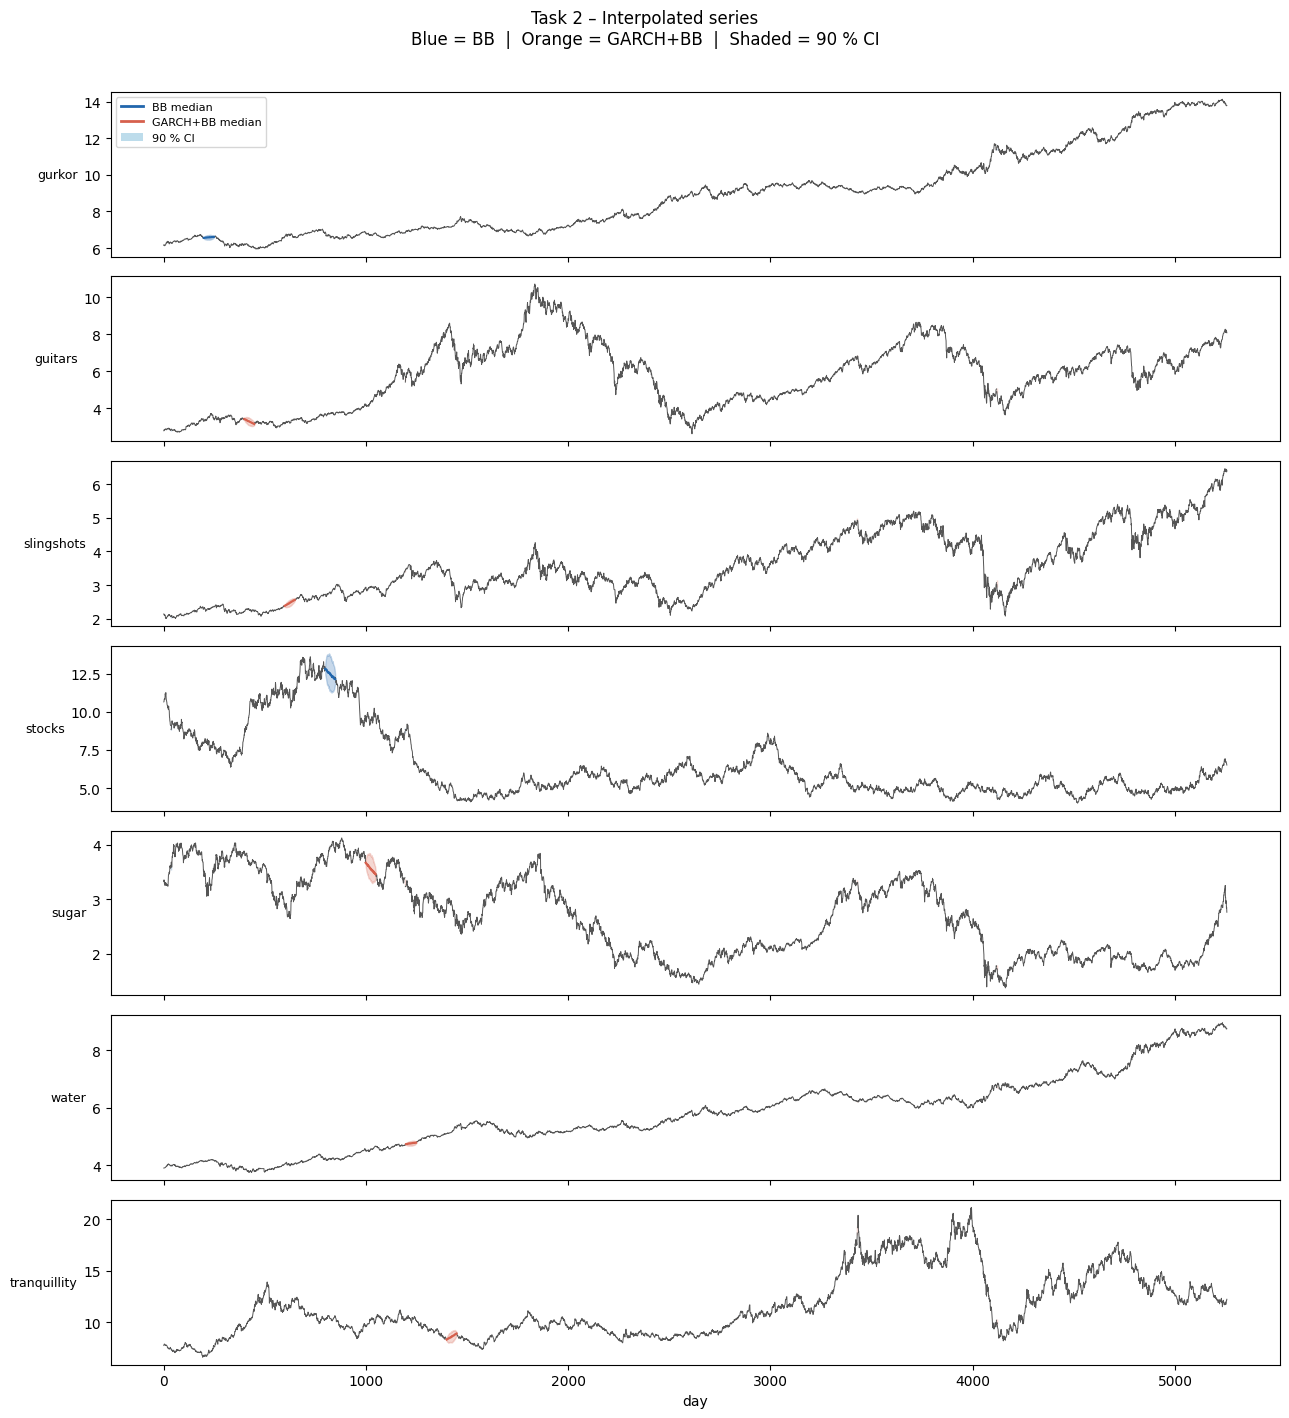

In [14]:
# ── Visualisation 1: Full price series with interpolated gaps highlighted ──
COLOR_BB    = '#2166ac'   # blue  — plain BB
COLOR_GARCH = '#d6604d'   # orange-red — GARCH+BB
COLOR_BAND  = '#92c5de'   # light blue band

fig, axes = plt.subplots(len(series_cols), 1,
                         figsize=(13, 2.0 * len(series_cols)), sharex=True)

for ax, c in zip(axes, series_cols):
    ax.plot(df.index, df[c], color='#555555', lw=0.7)   # observed (grey)

    gaps = get_internal_gaps(df[c])
    for (gs, ge, gl), frame in zip(gaps, interp_results[c]):
        method = frame['method'].iloc[0]
        col    = COLOR_GARCH if method == 'GARCH+BB' else COLOR_BB
        days   = frame.index.values
        med_p  = np.exp(frame['median'].values)
        lo_p   = np.exp(frame['p05'].values)
        hi_p   = np.exp(frame['p95'].values)
        ax.fill_between(days, lo_p, hi_p, color=col, alpha=0.25)
        ax.plot(days, med_p, color=col, lw=1.6)

    ax.set_ylabel(c, rotation=0, ha='right', va='center', fontsize=9)

axes[-1].set_xlabel('day')
fig.suptitle('Task 2 – Interpolated series\n'
             'Blue = BB  |  Orange = GARCH+BB  |  Shaded = 90 % CI', y=1.01)

legend_handles = [
    plt.Line2D([0], [0], color=COLOR_BB,    lw=2, label='BB median'),
    plt.Line2D([0], [0], color=COLOR_GARCH, lw=2, label='GARCH+BB median'),
    plt.Rectangle((0, 0), 1, 1, fc=COLOR_BAND, alpha=0.6, label='90 % CI'),
]
axes[0].legend(handles=legend_handles, fontsize=8, loc='upper left')

fig.tight_layout()
plt.show()

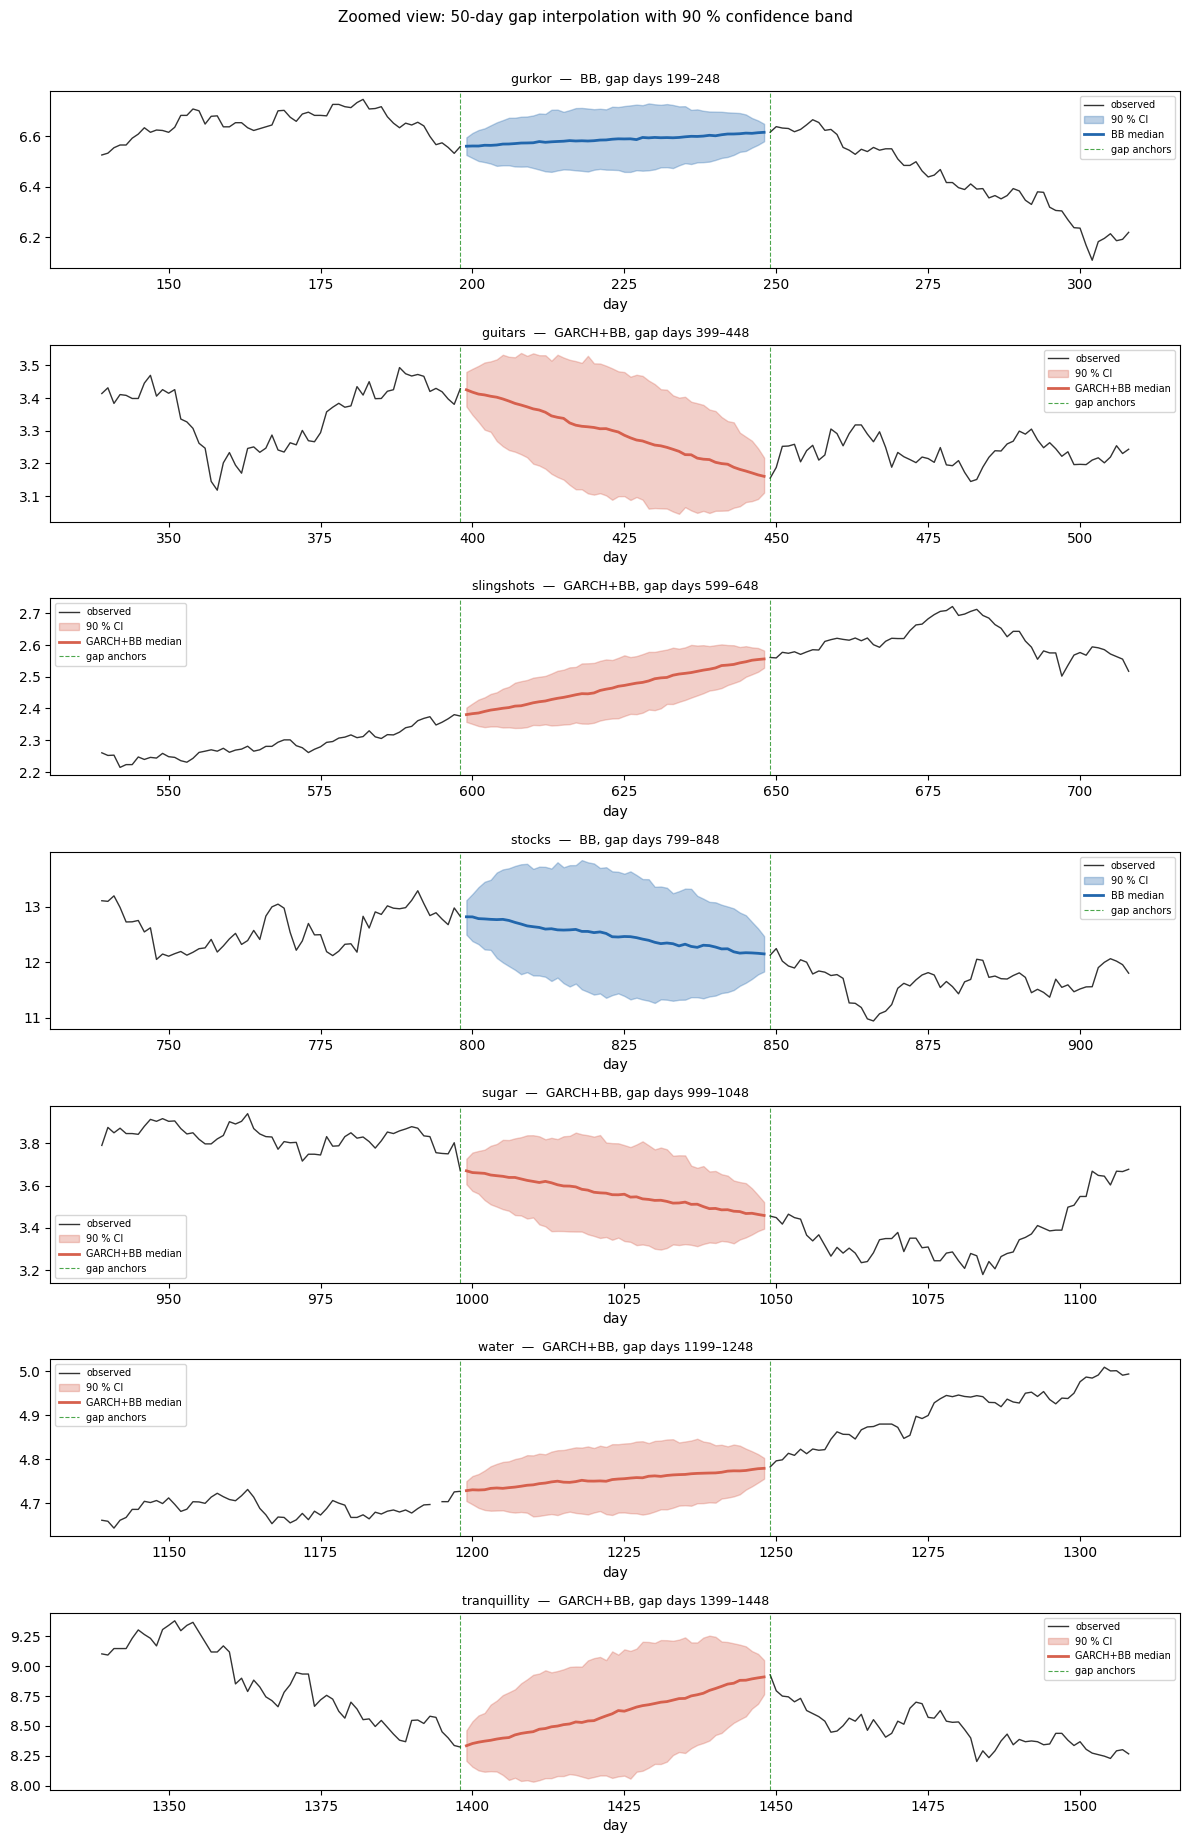

In [15]:
# ── Visualisation 2: Zoomed view of the 50-day gap with uncertainty bands ──
# For each series find its 50-day internal gap and plot ±60 days context.

CONTEXT = 60   # days to show on each side of the gap

fig, axes = plt.subplots(len(series_cols), 1,
                         figsize=(12, 2.6 * len(series_cols)))

for ax, c in zip(axes, series_cols):
    # Find the 50-day gap
    gaps = get_internal_gaps(df[c])
    big_gap = next((g for g in gaps if g[2] == 50), None)
    if big_gap is None:
        ax.set_visible(False)
        continue

    gs, ge, gl = big_gap
    frame = interp_results[c][gaps.index(big_gap)]
    method = frame['method'].iloc[0]
    col    = COLOR_GARCH if method == 'GARCH+BB' else COLOR_BB

    x_lo = max(1,    gs - CONTEXT)
    x_hi = min(df.index.max(), ge + CONTEXT)
    window = df.loc[x_lo:x_hi, c]

    ax.plot(window.index, window.values, color='#333333', lw=1.0,
            label='observed')

    # Uncertainty band (price space)
    days  = frame.index.values
    med_p = np.exp(frame['median'].values)
    lo_p  = np.exp(frame['p05'].values)
    hi_p  = np.exp(frame['p95'].values)

    ax.fill_between(days, lo_p, hi_p, color=col, alpha=0.30,
                    label='90 % CI')
    ax.plot(days, med_p, color=col, lw=2.0, label=f'{method} median')

    # Mark anchors
    a_day = gs - 1
    b_day = ge + 1
    ax.axvline(a_day, color='green', lw=0.8, ls='--', alpha=0.7)
    ax.axvline(b_day, color='green', lw=0.8, ls='--', alpha=0.7,
               label='gap anchors')

    ax.set_title(f'{c}  —  {method}, gap days {gs}–{ge}', fontsize=9)
    ax.legend(fontsize=7, loc='best')
    ax.set_xlabel('day')

fig.suptitle('Zoomed view: 50-day gap interpolation with 90 % confidence band',
             y=1.01, fontsize=11)
fig.tight_layout()
plt.show()

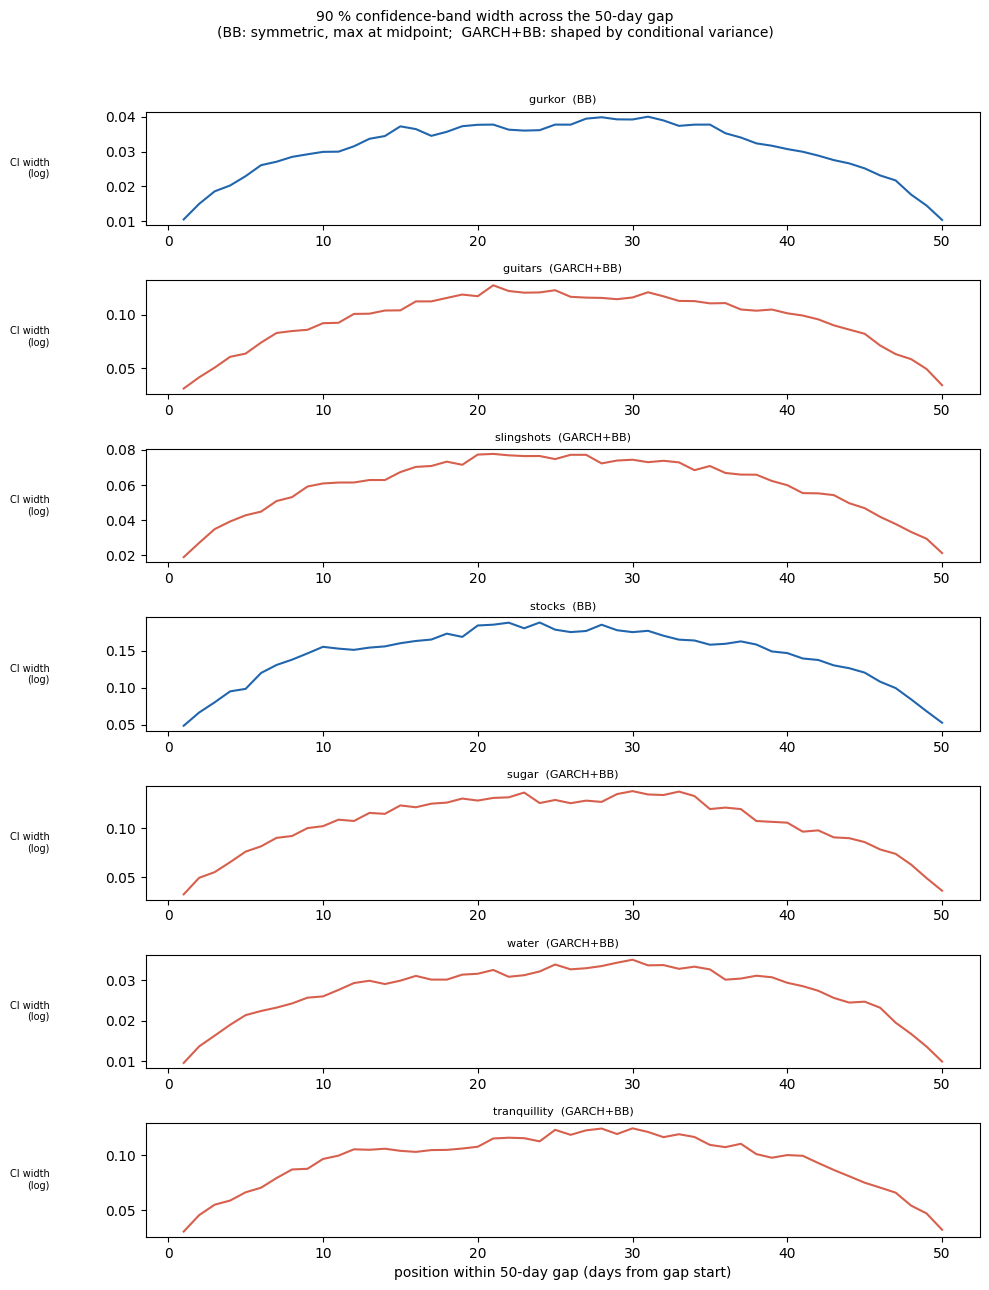

In [16]:
# ── Visualisation 3: Uncertainty width across the 50-day gap ──────────────
# Shows how wide the 90 % CI is (in log-price units) at each point in the gap.
# For GARCH+BB the width can be non-symmetric around the midpoint.

fig, axes = plt.subplots(len(series_cols), 1,
                         figsize=(10, 1.8 * len(series_cols)), sharex=False)

for ax, c in zip(axes, series_cols):
    gaps = get_internal_gaps(df[c])
    big_gap = next((g for g in gaps if g[2] == 50), None)
    if big_gap is None:
        ax.set_visible(False)
        continue

    gs, ge, _ = big_gap
    frame = interp_results[c][gaps.index(big_gap)]
    method = frame['method'].iloc[0]
    col    = COLOR_GARCH if method == 'GARCH+BB' else COLOR_BB

    width = frame['p95'].values - frame['p05'].values   # 90 % CI width in log-price

    t_rel = np.arange(1, len(width) + 1)
    ax.plot(t_rel, width, color=col, lw=1.5)
    ax.set_ylabel('CI width\n(log)', fontsize=7, rotation=0, ha='right', va='center',
                  labelpad=40)
    ax.set_title(f'{c}  ({method})', fontsize=8)

axes[-1].set_xlabel('position within 50-day gap (days from gap start)')
fig.suptitle('90 % confidence-band width across the 50-day gap\n'
             '(BB: symmetric, max at midpoint;  GARCH+BB: shaped by conditional variance)',
             y=1.02, fontsize=10)
fig.tight_layout()
plt.show()

In [17]:
# ── Summary table: all gaps, methods used, and uncertainty statistics ──────
summary_df = pd.DataFrame(method_log)

# Attach the median-path 90%-CI half-width for the 50-day gaps (log-price units)
ci_stats = []
for _, row in summary_df.iterrows():
    c  = row['series']
    gs = row['gap_start']
    ge = row['gap_end']
    gaps = get_internal_gaps(df[c])
    idx  = next(i for i, (a,b,l) in enumerate(gaps) if a == gs and b == ge)
    frame = interp_results[c][idx]
    ci_half = float((frame['p95'] - frame['p05']).mean() / 2)
    ci_stats.append(ci_half)

summary_df['mean_90CI_half (log)'] = ci_stats
print("Interpolation summary — all internal gaps:\n")
print(summary_df.to_string(index=False))

Interpolation summary — all internal gaps:

      series  gap_start  gap_end  gap_len   method  mean_90CI_half (log)
      gurkor         36       36        1       BB              0.004332
      gurkor        199      248       50       BB              0.015367
      gurkor       1194     1194        1       BB              0.004347
      gurkor       2836     2836        1       BB              0.004122
      gurkor       3430     3430        1       BB              0.004224
      gurkor       4118     4118        1       BB              0.004553
     guitars         36       36        1       BB              0.016767
     guitars        399      448       50 GARCH+BB              0.047631
     guitars       1194     1194        1 GARCH+BB              0.017565
     guitars       2836     2836        1 GARCH+BB              0.011423
     guitars       3430     3430        1 GARCH+BB              0.009926
     guitars       4118     4118        1 GARCH+BB              0.024600
  sling

## 3. Summary

### Method assignment

| Series | Method | Justification |
|--------|--------|---------------|
| **gurkor** | Plain BB | ACF(r²) lag 1 ≈ 0.05; rolling volatility flat; no significant LB test |
| **water** | Plain BB | Lowest volatility of all series; ACF(r²) ≈ 0.06; no significant clustering |
| **stocks** | Plain BB | ACF(r²) ≈ 0; excess kurtosis ≈ 0 (near-Gaussian); textbook absence of GARCH effects |
| **guitars** | BB + GARCH(1,1) | ACF(r²) lag 1 ≈ 0.22; excess kurtosis 5.55; volatility spikes days 2000–3000 |
| **slingshots** | BB + GARCH(1,1) | Strongest persistent ACF(r²) ≈ 0.32; excess kurtosis 6.43; crash around day 4000 |
| **sugar** | BB + GARCH(1,1) | Highest ACF(r²) lag 1 ≈ 0.60; excess kurtosis 10.69; extreme spike pair at day 4100 |
| **tranquillity** | BB + GARCH(1,1) | ACF(r²) ≈ 0.12; moderate clustering consistent with three-phase price regime |

*Note: any gap where pre-gap data < 60 observations (e.g. day-36 single-day gap for GARCH series) automatically falls back to plain BB.*

### Expected quality of the interpolations

- **Single-day gaps (days 36, 1194, 2836, 3430, 4118):** Both methods reduce to a single point drawn between two known anchors. Uncertainty is very small (one-step bridge variance). Quality is essentially exact conditional on the model.

- **50-day gaps:** The BB confidence band is widest at the midpoint and tapers to zero at both anchors. For plain BB, the band is perfectly symmetric and grows as σ√(t(T−t)/T). For GARCH+BB, the band is non-symmetric — it is wider in periods that the GARCH model identifies as high-volatility and narrower elsewhere.

- **Potential limitations:**
  - The bridge conditions on the endpoint but not on any intra-gap dynamics; large regime shifts inside the gap will be missed.
  - GARCH parameters are estimated on pre-gap data; if the volatility regime changes at the gap, the model may be mis-specified.
  - For very early gaps (day-36 or the early 50-day gaps for gurkor/guitars) the pre-gap window is short, so σ is estimated with higher uncertainty — handled by the min_pre fallback.

### Output

`df_interp` contains the fully interpolated dataset for Task 2. The trailing-200-day block (days 5257–5456) remains `NaN` and is reserved for Task 3.